# অধ্যায় ৮: উপসংহার
## পাঠ ৮.১: এমএল সমস্যা সমাধানের পদ্ধতি

আজ আমরা শিখব কীভাবে একটি বাস্তব সমস্যাকে মেশিন লার্নিং-এর মাধ্যমে সমাধান করা যায়। আমরা একটি সম্পূর্ণ ML প্রজেক্টের স্টেপগুলো দেখব—সমস্যা বোঝা থেকে শুরু করে মডেল ডিপ্লয়মেন্ট পর্যন্ত।

### A. গল্প: রোগ নির্ণয় অ্যাপ

তোমার ছোট বোনের স্কুলে একটি মহামারী ছড়িয়েছে—অনেক শিশু জ্বরে ভুগছে। ডাক্তাররা চায় একটি অ্যাপ যা দিয়ে বাবা-মারা বাড়িতে বসেই বুঝতে পারবে সন্তানের জ্বর সাধারণ ভাইরাস নাকি ডেঙ্গু।

তুমি এই সমস্যা সমাধানের জন্য ML মডেল বানাবে। কীভাবে এগোবে?

### B. ML সমস্যা সমাধানের ৭টি ধাপ

**ধাপ ১: সমস্যা বুঝো (Problem Understanding)**
- কী ধরনের সমস্যা? ক্লাসিফিকেশন, রিগ্রেশন, নাকি অন্য কিছু?
- সাফল্যের মাপকাঠি কী? (যেমন: ৯০% Recall)<
- কারা এই মডেল ব্যবহার করবে?

**ধাপ ২: ডেটা সংগ্রহ করো (Data Collection)**
- কী কী ডেটা দরকার? (লক্ষণ, বয়স, রক্ত পরীক্ষা, ইত্যাদি)
- কত ডেটা দরকার? (সাধারণত কয়েক হাজার নমুনা)
- ডেটা কি ব্যালেন্সড? (ডেঙ্গু রোগী বিরল হতে পারে)

**ধাপ ৩: ডেটা প্রিপ্রসেস করো (Data Preprocessing)**
- মিসিং ভ্যালু: কী করবে?
- ক্যাটাগরিক্যাল ডেটা: এনকোডিং
- ফিচার স্কেলিং
- ফিচার সিলেকশন

**ধাপ ৪: বেসলাইন মডেল তৈরি করো (Baseline Model)**
- প্রথমে একটি সহজ মডেল তৈরি করো
- DummyClassifier বা সহজ Logistic Regression
- বেসলাইন বোঝায় ন্যূনতম কী পাওয়া সম্ভব

**ধাপ ৫: মডেল উন্নত করো (Model Improvement)**
- জটিল মডেল ট্রাই করো (Random Forest, Gradient Boosting)
- GridSearchCV দিয়ে প্যারামিটার টিউন করো
- ক্রস-ভ্যালিডেশন ব্যবহার করো

**ধাপ ৬: মডেল মূল্যায়ন করো (Model Evaluation)**
- শুধু Accuracy নয়, Precision, Recall, F1, AUC দেখো
- কনফিউশন ম্যাট্রিক্স বিশ্লেষণ করো
- টেস্ট ডেটায় ফাইনাল ইভালুয়েশন

**ধাপ ৭: মডেল ডিপ্লয় করো (Deployment)**
- পাইপলাইন তৈরি করো
- মডেল সেভ করো (pickle/joblib)
- একটি API বা অ্যাপ তৈরি করো

In [1]:
# প্রয়োজনীয় লাইব্রেরি
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)
print('ML প্রজেক্ট ওয়ার্কফ্লো শুরু হচ্ছে...')

ML প্রজেক্ট ওয়ার্কফ্লো শুরু হচ্ছে...


### C. সম্পূর্ণ উদাহরণ: একটি ML সমস্যা সমাধান

আমরা একটি সিন্থেটিক ডেটাসেট তৈরি করব যা একটি রোগ নির্ণয়ের সমস্যা অনুকরণ করে।

In [2]:
# ধাপ 1-2: সিন্থেটিক ডেটা তৈরি
np.random.seed(42)
n_samples = 2000

X, y = make_classification(
    n_samples=n_samples,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    weights=[0.85, 0.15],  # 15% পজিটিভ (রোগী)
    random_state=42
)

feature_names = [f'লক্ষণ_{i+1}' for i in range(10)]
df = pd.DataFrame(X, columns=feature_names)
df['রোগী'] = y
print('ধাপ 1-2: ডেটা সংগ্রহ')
print(f'মোট নমুনা: {n_samples}')
print(f'ফিচার: {len(feature_names)}টি')
print(f'সুস্থ: {np.sum(y==0)} ({np.mean(y==0)*100:.1f}%)')
print(f'রোগী: {np.sum(y==1)} ({np.mean(y==1)*100:.1f}%)')
print(f'\nপ্রথম 5টি নমুনা:')
print(df.head())

ধাপ 1-2: ডেটা সংগ্রহ
মোট নমুনা: 2000
ফিচার: 10টি
সুস্থ: 1695 (84.8%)
রোগী: 305 (15.2%)

প্রথম 5টি নমুনা:
    লক্ষণ_1   লক্ষণ_2   লক্ষণ_3   লক্ষণ_4   লক্ষণ_5   লক্ষণ_6   লক্ষণ_7  \
0 -0.527985  2.502247  0.695293 -1.795216 -1.116564 -1.533083 -2.463545   
1 -0.969457 -0.027843  0.491814 -0.904605  0.095751  1.047343 -0.838283   
2 -0.233425 -1.991787 -0.457817 -0.407070 -2.221362 -2.598014  0.857989   
3 -1.746842  1.005994 -1.276618 -2.529162 -1.537575 -2.303886 -0.133311   
4 -1.297131 -1.451861  1.791782 -0.512722 -0.622481 -1.066218 -1.250867   

    লক্ষণ_8   লক্ষণ_9  লক্ষণ_10  রোগী  
0  1.197423 -1.900653  3.487929     0  
1 -0.857172 -0.848319  0.039613     0  
2 -0.579129 -1.251154  0.165376     0  
3 -0.748383  0.509019  2.254463     0  
4 -0.000132 -0.928541  0.423256     0  


In [3]:
# ধাপ 3: ডেটা প্রিপ্রসেসিং ও স্প্লিট
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('ধাপ 3: ডেটা প্রিপ্রসেসিং')
print(f'ট্রেন: {X_train.shape[0]}টি, টেস্ট: {X_test.shape[0]}টি')
print('পাইপলাইনে স্কেলিং যোগ করা হবে')

ধাপ 3: ডেটা প্রিপ্রসেসিং
ট্রেন: 1600টি, টেস্ট: 400টি
পাইপলাইনে স্কেলিং যোগ করা হবে


In [4]:
# ধাপ 4: বেসলাইন মডেল
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
print('ধাপ 4: বেসলাইন মডেল (DummyClassifier)')
print(f'Accuracy: {accuracy_score(y_test, y_pred_dummy):.4f}')
print(f'(সবাইকে "সুস্থ" বললে এটুকুই পাওয়া যায়)')
print('\nতবে Accuracy দিয়ে বোঝা যাচ্ছে না—Recall দেখি:')
print(classification_report(y_test, y_pred_dummy, target_names=['সুস্থ', 'রোগী'], zero_division=0))

ধাপ 4: বেসলাইন মডেল (DummyClassifier)
Accuracy: 0.8475
(সবাইকে "সুস্থ" বললে এটুকুই পাওয়া যায়)

তবে Accuracy দিয়ে বোঝা যাচ্ছে না—Recall দেখি:
              precision    recall  f1-score   support

       সুস্থ       0.85      1.00      0.92       339
        রোগী       0.00      0.00      0.00        61

    accuracy                           0.85       400
   macro avg       0.42      0.50      0.46       400
weighted avg       0.72      0.85      0.78       400



In [5]:
# ধাপ 5: পাইপলাইন দিয়ে মডেল
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [5, 10, None]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid.fit(X_train, y_train)
print('ধাপ 5: GridSearchCV দিয়ে মডেল উন্নত করা')
print(f'সেরা প্যারামিটার: {grid.best_params_}')
print(f'সেরা CV Recall: {grid.best_score_:.4f}')

ধাপ 5: GridSearchCV দিয়ে মডেল উন্নত করা
সেরা প্যারামিটার: {'rf__max_depth': None, 'rf__n_estimators': 50}
সেরা CV Recall: 0.7371


ধাপ 6: মডেল মূল্যায়ন
Classification Report:
              precision    recall  f1-score   support

       সুস্থ       0.97      0.99      0.98       339
        রোগী       0.93      0.84      0.88        61

    accuracy                           0.96       400
   macro avg       0.95      0.91      0.93       400
weighted avg       0.96      0.96      0.96       400

ROC-AUC Score: 0.9712


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2497 (\N{BENGALI VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: Us

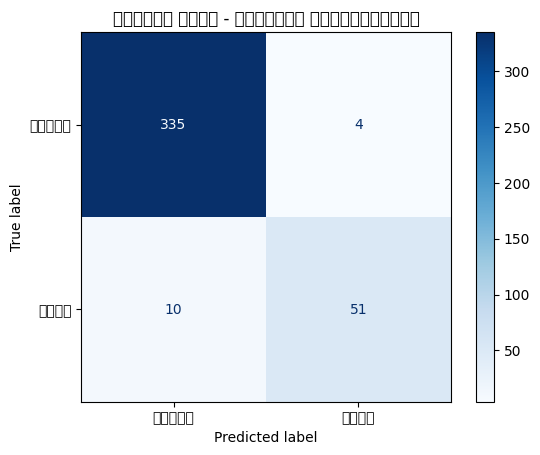

In [6]:
# ধাপ 6: মডেল মূল্যায়ন
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]
print('ধাপ 6: মডেল মূল্যায়ন')
print('=' * 50)
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['সুস্থ', 'রোগী']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['সুস্থ', 'রোগী'])
disp.plot(cmap='Blues')
plt.title('ফাইনাল মডেল - কনফিউশন ম্যাট্রিক্স')
plt.show()

### D. প্রশ্নগুলো যা ML প্রজেক্টের আগে জিজ্ঞেস করতে হবে

**ডেটা সম্পর্কে:**
- আমাদের কাছে যথেষ্ট ডেটা আছে?
- ডেটা কি লেবেলযুক্ত (labeled)?
- ডেটায় কি বায়াস আছে?
- ডেটা প্রাইভেসি ইস্যু আছে কি?

**মেট্রিক সম্পর্কে:**
- সাফল্যের মাপকাঠি কী?
- False Positive এবং False Negative-র মধ্যে কোনটি বেশি ক্ষতিকর?
- ব্যবহারকারীরা কী বুঝবে?

**মডেল সম্পর্কে:**
- মডেলটি কি ব্যাখ্যাযোগ্য (explainable)?
- কত দ্রুত প্রেডিকশন দরকার?
- মডেলটি কি নিয়মিত আপডেট করতে হবে?

**হিউম্যান ইন দ্য লুপ (Human in the Loop):**
- মডেলের সিদ্ধান্ত কি সবসময় চূড়ান্ত, নাকি একজন মানুষ চেক করবে?
- সিস্টেম কি ব্যাখ্যা দিতে পারবে কেন এই সিদ্ধান্ত নিয়েছে?
- মডেল ভুল করলে কী হবে?

In [7]:
# ধাপ 7: ডিপ্লয়মেন্টের জন্য প্রস্তুতি
import joblib

# ফাইনাল পাইপলাইন
final_pipe = grid.best_estimator_

# একটি নতুন নমুনা কল্পনা করি
new_patient = np.random.randn(1, 10)
prediction = final_pipe.predict(new_patient)
probability = final_pipe.predict_proba(new_patient)[0, 1]
print('ধাপ 7: নতুন রোগী পরীক্ষা')
print(f'রোগী হওয়ার সম্ভাবনা: {probability*100:.1f}%')
if prediction[0] == 1:
    print('⚠️ সতর্কতা: রোগী শনাক্ত হয়েছে!')
else:
    print('✅ রোগী সুস্থ (মডেলের মতে)')
print('\nমডেলটি pickle/save করে API তে ব্যবহার করা যাবে')

ধাপ 7: নতুন রোগী পরীক্ষা
রোগী হওয়ার সম্ভাবনা: 84.0%
⚠️ সতর্কতা: রোগী শনাক্ত হয়েছে!

মডেলটি pickle/save করে API তে ব্যবহার করা যাবে


### E. তুমি কি বুঝতে পেরেছ?

**প্রশ্ন ১:** ML প্রজেক্টের ৭টি ধাপ কী কী?

**প্রশ্ন ২:** বেসলাইন মডেল কেন তৈরি করি?

**প্রশ্ন ৩:** 'Human in the Loop' বলতে কী বোঝায়?

**প্রশ্ন ৪:** ML প্রজেক্ট শুরুর আগে কী কী প্রশ্ন জিজ্ঞেস করা উচিত?

### F. সারসংক্ষেপ

আজ আমরা শিখলাম:
✅ ML প্রজেক্টের ৭টি ধাপ: সমস্যা বুঝো → ডেটা সংগ্রহ → প্রিপ্রসেস → বেসলাইন → উন্নত করো → মূল্যায়ন করো → ডিপ্লয় করো
✅ বেসলাইন মডেল ন্যূনতম প্রত্যাশা নির্ধারণ করে
✅ সঠিক মেট্রিক বাছাই করা গুরুত্বপূর্ণ (শুধু Accuracy নয়)
✅ GridSearchCV + পাইপলাইন উন্নত মডেল তৈরি করে
✅ 'Human in the Loop' ML সিস্টেমকে নিরাপদ ও নির্ভরযোগ্য করে
✅ মডেল তৈরির আগে এবং পরে অনেক গুরুত্বপূর্ণ প্রশ্নের উত্তর দিতে হবে

পরবর্তী (এবং শেষ) পাঠে আমরা প্রোটোটাইপ থেকে প্রোডাকশন পর্যন্ত যাত্রা নিয়ে শিখব!